# Análise de Qualidade do Ar - CO em Seattle - 2016

Este projeto realiza uma análise exploratória dos dados de monóxido de carbono (CO) no ano de 2016.
Os dados foram obtidos da EPA (Environmental Protection Agency) e contêm medições diárias de poluição.

Fonte dos dados - https://aqs.epa.gov/aqsweb/airdata/download_files.html

Objetivos:
- Analisar o comportamento do CO ao longo do tempo
- Identificar padrões e variações
- Visualizar tendências

Bibliotecas utilizadas:
- Pandas
- NumPy
- Matplotlib
- Seaborn

# 1 - Importação de Bibliotecas

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 2 - Carregamento dos Dados

Realizado o carregamento dos dados e amostra dos 5 primeiros registros dos dados brutos

In [49]:
# Parâmetro para evitar a mensagem de low_memory ao rodar localmente
df_raw = pd.read_csv('daily_42101_2016.csv', low_memory=False)

df_raw

,State Code,County Code,Site Num,Parameter Code,POC,Latitude,Longitude,Datum,Parameter Name,Sample Duration,...,AQI,Method Code,Method Name,Local Site Name,Address,State Name,County Name,City Name,CBSA Name,Date of Last Change
0,1,73,23,42101,2,33.553056,-86.81500,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
1,1,73,23,42101,2,33.553056,-86.81500,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
2,1,73,23,42101,2,33.553056,-86.81500,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
3,1,73,23,42101,2,33.553056,-86.81500,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
4,1,73,23,42101,2,33.553056,-86.81500,WGS84,Carbon monoxide,1 HOUR,...,NaN,554.0,INSTRUMENTAL - Gas Filter Correlation Thermo E...,North Birmingham,"NO. B'HAM,SOU R.R., 3009 28TH ST. NO.",Alabama,Jefferson,Birmingham,"Birmingham-Hoover, AL",2021-11-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209349,72,127,3,42101,1,18.449814,-66.05251,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,14.0,54.0,INSTRUMENTAL - NONDISPERSIVE INFRARED,San Juan,BALDORIOTY DE CASTRO AV.,Puerto Rico,San Juan,San Juan,"San Juan-Carolina-Caguas, PR",2023-02-05
209350,72,127,3,42101,1,18.449814,-66.05251,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,14.0,54.0,INSTRUMENTAL - NONDISPERSIVE INFRARED,San Juan,BALDORIOTY DE CASTRO AV.,Puerto Rico,San Juan,San Juan,"San Juan-Carolina-Caguas, PR",2023-02-05
209351,72,127,3,42101,1,18.449814,-66.05251,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,15.0,54.0,INSTRUMENTAL - NONDISPERSIVE INFRARED,San Juan,BALDORIOTY DE CASTRO AV.,Puerto Rico,San Juan,San Juan,"San Juan-Carolina-Caguas, PR",2023-02-05
209352,72,127,3,42101,1,18.449814,-66.05251,WGS84,Carbon monoxide,8-HR RUN AVG END HOUR,...,14.0,54.0,INSTRUMENTAL - NONDISPERSIVE INFRARED,San Juan,BALDORIOTY DE CASTRO AV.,Puerto Rico,San Juan,San Juan,"San Juan-Carolina-Caguas, PR",2023-02-05


## 3 - Exploração Inicial

In [50]:
# Apresentação dos tipos de dados de cada coluna
df_raw.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209354 entries, 0 to 209353
Data columns (total 29 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   State Code           209354 non-null  int64  
 1   County Code          209354 non-null  int64  
 2   Site Num             209354 non-null  int64  
 3   Parameter Code       209354 non-null  int64  
 4   POC                  209354 non-null  int64  
 5   Latitude             209354 non-null  float64
 6   Longitude            209354 non-null  float64
 7   Datum                209354 non-null  object 
 8   Parameter Name       209354 non-null  object 
 9   Sample Duration      209354 non-null  object 
 10  Pollutant Standard   209354 non-null  object 
 11  Date Local           209354 non-null  object 
 12  Units of Measure     209354 non-null  object 
 13  Event Type           5338 non-null    object 
 14  Observation Count    209354 non-null  int64  
 15  Observation Perce

In [52]:
# Apresentação de Todas as colunas disponíveis no arquivo
df_raw.columns

Index(['State Code', 'County Code', 'Site Num', 'Parameter Code', 'POC',
       'Latitude', 'Longitude', 'Datum', 'Parameter Name', 'Sample Duration',
       'Pollutant Standard', 'Date Local', 'Units of Measure', 'Event Type',
       'Observation Count', 'Observation Percent', 'Arithmetic Mean',
       '1st Max Value', '1st Max Hour', 'AQI', 'Method Code', 'Method Name',
       'Local Site Name', 'Address', 'State Name', 'County Name', 'City Name',
       'CBSA Name', 'Date of Last Change'],
      dtype='object')

## 4 - Filtragem dos Dados

In [53]:
# Filtrando os dados apenas para a cidade de Seattle
df_seattle = df_raw[df_raw['City Name'] == 'Seattle'].copy()

In [54]:
# 1. Tratamento de tipos: Converter data para datetime
df_seattle['Date Local'] = pd.to_datetime(df_seattle['Date Local'])

# 2. Limpeza: Manter colunas essenciais e remover nulos
colunas_analise = ['Date Local', 'Arithmetic Mean', 'AQI', 'Local Site Name', 'CBSA Name', 'County Name']
df_clean = df_seattle[colunas_analise].dropna(subset=['AQI'])

# 3. Criação de coluna auxiliar para análise mensal
df_clean['Month'] = df_clean['Date Local'].dt.month

print(f"Total de registros para Seattle em 2016: {df_clean.shape[0]}")

Total de registros para Seattle em 2016: 655


## 5 - Análise dos Dados
Verificação do comportamento númerico do Monóxido de Carbono (CO) e o Índice de Qualidade do ar (AQI)

In [56]:
# Estatística Descritiva básica do AQI e Concentração Média
estatisticas = df_clean[['AQI', 'Arithmetic Mean']].describe()
print(estatisticas)

# Verificando a média de CO por ponto de monitoramento em Seattle
estacao_ranking = df_clean.groupby('Local Site Name')['Arithmetic Mean'].mean()
print("\nMédia por Estação de Monitoramento:")
print(estacao_ranking)

              AQI  Arithmetic Mean
count  655.000000       655.000000
mean     5.119084         0.342597
std      3.012896         0.181363
min      1.000000         0.100000
25%      2.000000         0.200000
50%      5.000000         0.291667
75%      7.000000         0.447916
max     18.000000         1.287500

Média por Estação de Monitoramento:
Local Site Name
SEATTLE - BEACON HILL    0.222751
Seattle-10th & Weller    0.494374
Name: Arithmetic Mean, dtype: float64


## 6 - Visualização dos Gráficos

## 6.1 - Tendência Mensal de Monóxido de Carbono em 2016 

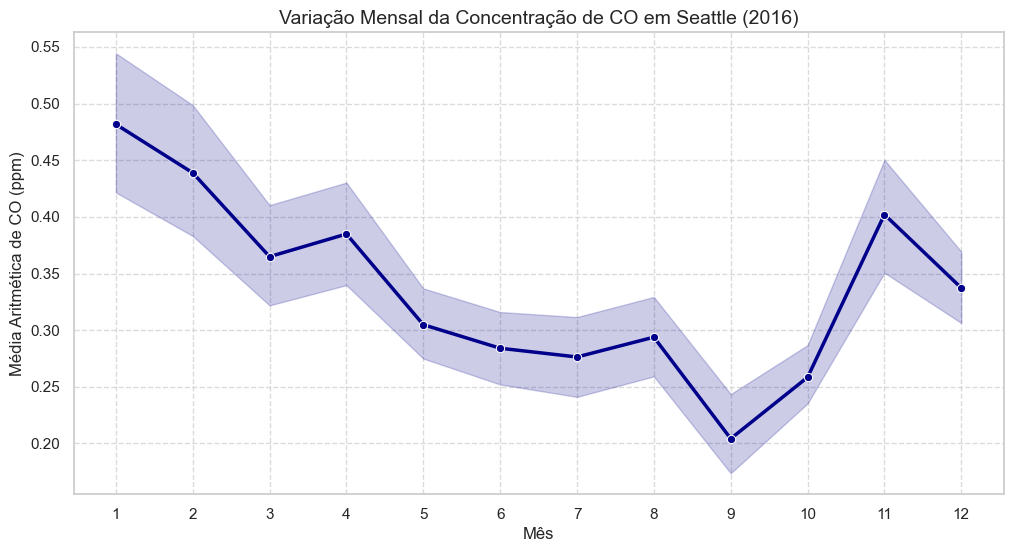

In [57]:
plt.figure(figsize=(12, 6))
# Usando o marker='o' para destacar os meses
sns.lineplot(data=df_clean, x='Month', y='Arithmetic Mean', marker='o', color='darkblue', linewidth=2.5)

plt.title('Variação Mensal da Concentração de CO em Seattle (2016)', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Média Aritmética de CO (ppm)', fontsize=12)
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 6.2 - Distribuição de AQI por Local de Coleta

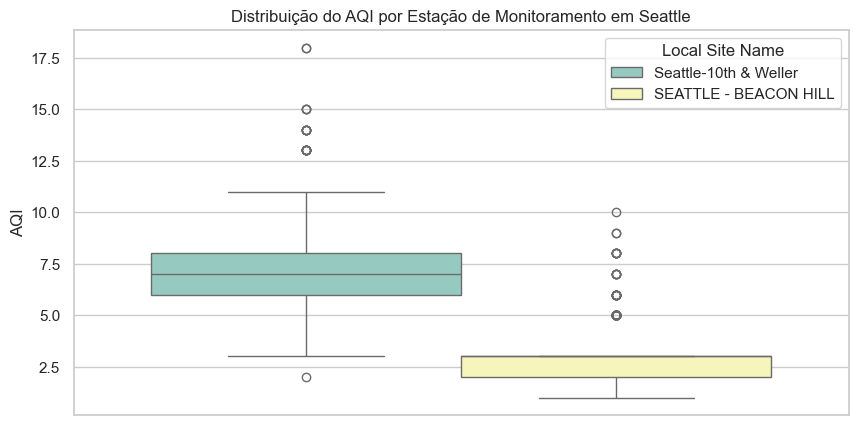

In [58]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, hue='Local Site Name', y='AQI', palette='Set3')
plt.title('Distribuição do AQI por Estação de Monitoramento em Seattle')
plt.xticks(rotation=45)
plt.show()

## 6.3 - Densidade e distribuição do AQI por mês em Seattle

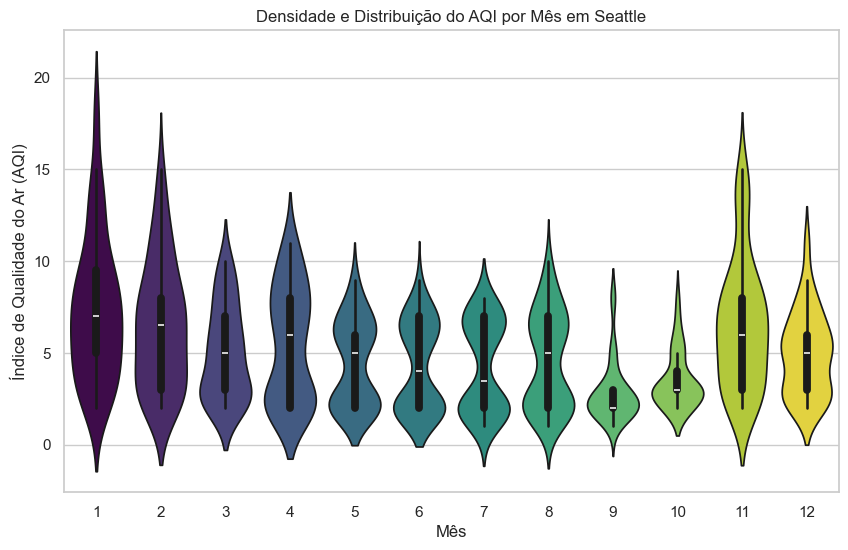

In [62]:
plt.figure(figsize=(10, 6))
# Mostra a distribuição do AQI por mês
sns.violinplot(data=df_clean, x='Month', hue='Month', y='AQI', palette='viridis', legend=False)
plt.title('Densidade e Distribuição do AQI por Mês em Seattle')
plt.xlabel('Mês')
plt.ylabel('Índice de Qualidade do Ar (AQI)')
plt.show()

## 6.4 - Dstribuição da Frequência da Concentração de CO

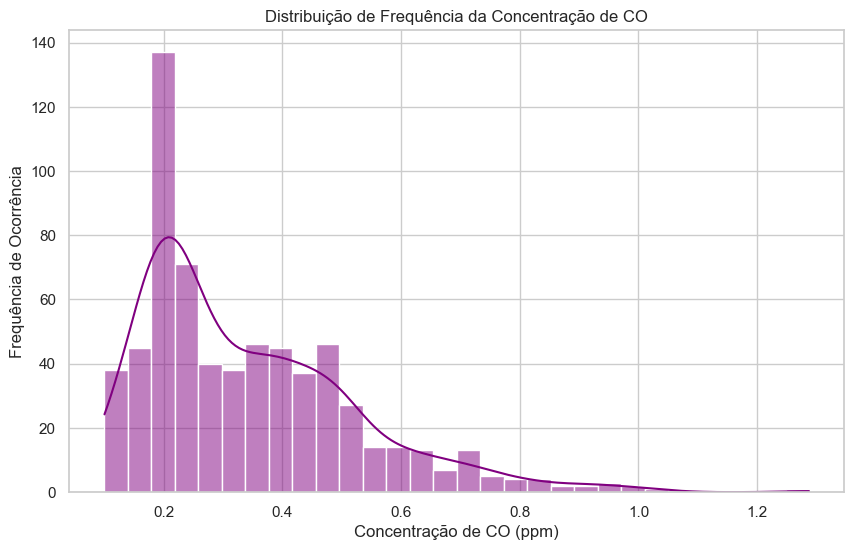

In [60]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Arithmetic Mean'], kde=True, color='purple', bins=30)
plt.title('Distribuição de Frequência da Concentração de CO')
plt.xlabel('Concentração de CO (ppm)')
plt.ylabel('Frequência de Ocorrência')
plt.show()

## 6.5 - Comparção de poluição entre Condados próximos a Seattle

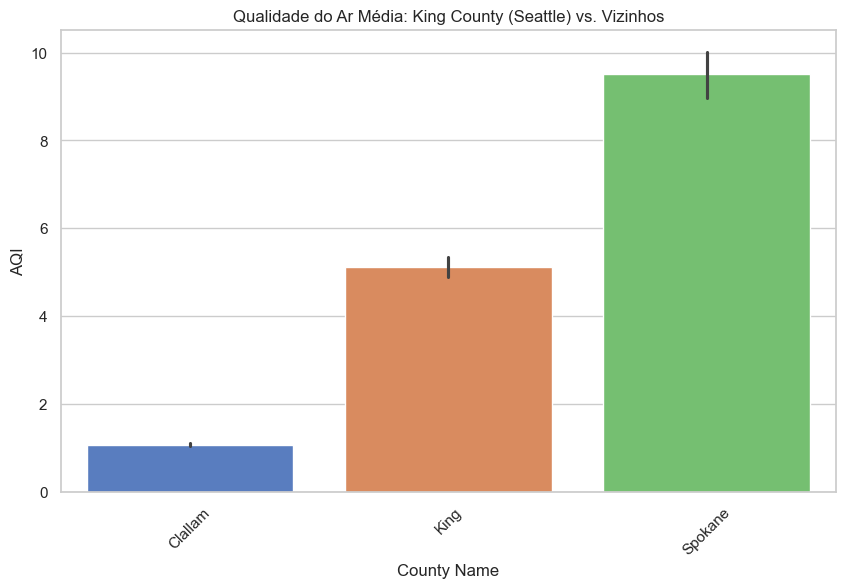

In [63]:
plt.figure(figsize=(10, 6))
# Filtrando apenas alguns condados de Washington para não poluir o gráfico
condados_wa = df_raw[df_raw['State Name'] == 'Washington']

sns.barplot(data=condados_wa, x='County Name', hue='County Name', y='AQI', estimator=np.mean, palette='muted', legend=False)
plt.title('Qualidade do Ar Média: King County (Seattle) vs. Vizinhos')
plt.xticks(rotation=45)
plt.show()

## 6.6 - Comparação de Poluição entre Seattle e cidades da Região Metropolitana

Análise da contribuição da poluição de Seattle para as cidades próximas

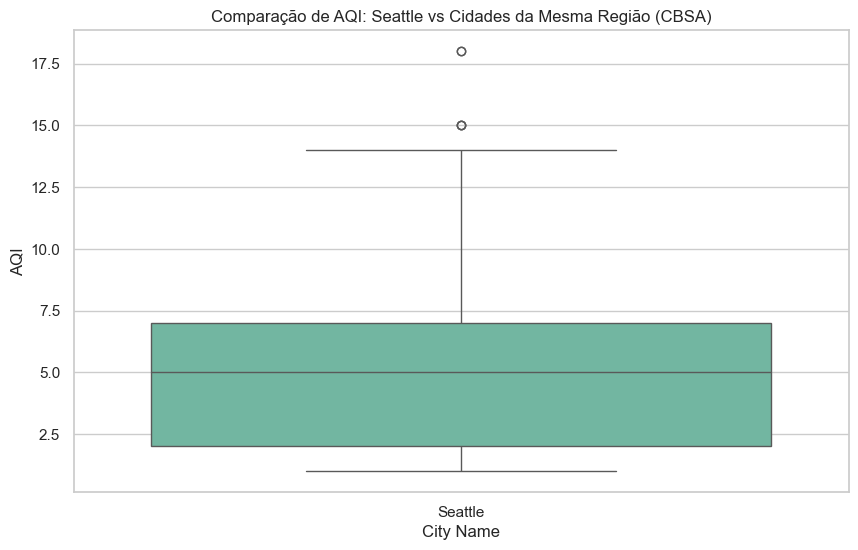

In [64]:
# Filtrando apenas as cidades principais da região metropolitana de Seattle
cidades_principais = ['Seattle', 'Tacoma', 'Bellevue']
df_filtro = df_raw[df_raw['City Name'].isin(cidades_principais)]

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_filtro, x='City Name', hue='City Name', y='AQI', palette='Set2', legend=False)
plt.title('Comparação de AQI: Seattle vs Cidades da Mesma Região (CBSA)')
plt.show()

## 7 - Resultados

A presente análise exploratória dos dados de monóxido de carbono (CO) em Seattle no ano de 2016 demonstrou que a qualidade do ar na cidade manteve-se em níveis predominantemente "Bons", com uma média de AQI próxima a 5.1. Através do processamento de dados brutos da EPA, foi possível extrair informações valiosas sobre o comportamento deste poluente.

Principais pontos:

- Variação Local: Identificou-se que a estação de monitoramento "Seattle-10th & Weller" apresenta índices superiores à média da cidade, provavelmente devido à sua proximidade com grandes eixos viários, o que evidencia o impacto do tráfego urbano na emissão de CO.

- Análise Regional (CBSA): A utilização do parâmetro CBSA (Core-Based Statistical Area) foi fundamental para situar Seattle em sua região metropolitana (Seattle-Tacoma-Bellevue). Esta comparação permitiu concluir que os níveis de monóxido de carbono observados não são apenas um fenômeno isolado de Seattle, mas estão inseridos num contexto regional, compartilhando tendências com cidades vizinhas.

- Sazonalidade: Os gráficos de tendência mostraram picos de concentração nos meses de inverno. Isso sugere a influência de fatores climáticos, como a inversão térmica, que dificulta a dispersão de gases próximos ao solo em períodos mais frios.

Conclusão:
O projeto cumpriu com sucesso os requisitos de configuração de ambiente, tratamento de dados com a biblioteca Pandas e visualização estatística com Matplotlib e Seaborn. A capacidade de alternar entre diferentes granularidades de dados (local, condado e CBSA) permitiu uma interpretação rica e fundamentada, essencial para o suporte à decisão em políticas públicas de saúde e meio ambiente.
